# Sales Data Analysis — End-to-End EDA

**Project overview**: This notebook cleans a raw e-commerce sales dataset, engineers useful time/location features, and explores sales patterns by product, time, city, state, and price. It also includes a market-basket analysis (which products are commonly bought together) and closes with a data-driven summary of key findings.

**Requirements**: `pandas`, `numpy`, `matplotlib`, `seaborn`
```
pip install pandas numpy matplotlib seaborn
```

**Input file expected**: `Sales_Data.csv` in the same directory as this notebook.

# Step 1 — Import Libraries & Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from itertools import combinations


In [2]:
df = pd.read_csv(r"D:\Teks project\Sales_Data.csv")
df.head()

,Unnamed: 0,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,City,Hour
0,0,295665,Macbook Pro Laptop,1.0,1700.00,2019-12-30 00:01:00,"136 Church St, New York City, NY 10001",12,1700.00,New York City,0
1,1,295666,LG Washing Machine,1.0,600.00,2019-12-29 07:03:00,"562 2nd St, New York City, NY 10001",12,600.00,New York City,7
2,2,295667,USB-C Charging Cable,1.0,11.95,2019-12-12 18:21:00,"277 Main St, New York City, NY 10001",12,11.95,New York City,18
3,3,295668,27in FHD Monitor,1.0,149.99,2019-12-22 15:13:00,"410 6th St, San Francisco, CA 94016",12,149.99,San Francisco,15
4,4,295669,USB-C Charging Cable,1.0,11.95,2019-12-18 12:38:00,"43 Hill St, Atlanta, GA 30301",12,11.95,Atlanta,12


# Step 2 — Understand The Dataset

In [3]:
df.shape

(185980, 11)

In [4]:
df.columns

Index(['Unnamed: 0', 'Order ID', 'Product', 'Quantity Ordered', 'Price Each',
       'Order Date', 'Purchase Address', 'Month', 'Sales', 'City', 'Hour'],
      dtype='object')

In [5]:
df.dtypes

Unnamed: 0            int64
Order ID              int64
Product              object
Quantity Ordered    float64
Price Each          float64
Order Date           object
Purchase Address     object
Month                 int64
Sales               float64
City                 object
Hour                  int64
dtype: object

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185980 entries, 0 to 185979
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        185980 non-null  int64  
 1   Order ID          185980 non-null  int64  
 2   Product           185960 non-null  object 
 3   Quantity Ordered  185960 non-null  float64
 4   Price Each        185960 non-null  float64
 5   Order Date        185980 non-null  object 
 6   Purchase Address  185980 non-null  object 
 7   Month             185980 non-null  int64  
 8   Sales             185960 non-null  float64
 9   City              185960 non-null  object 
 10  Hour              185980 non-null  int64  
dtypes: float64(3), int64(4), object(4)
memory usage: 15.6+ MB


In [7]:
df.describe()

,Unnamed: 0,Order ID,Quantity Ordered,Price Each,Month,Sales,Hour
count,185980.000000,185980.000000,185960.000000,185960.000000,185980.000000,185960.000000,185980.000000
mean,8340.601930,230415.700489,1.124860,184.426672,7.058990,185.545284,14.413367
std,5450.730203,51514.043323,0.447539,332.798747,3.503063,333.104119,5.423351
min,0.000000,141234.000000,1.000000,2.990000,1.000000,2.990000,0.000000
25%,3894.000000,185828.750000,1.000000,11.950000,4.000000,11.950000,11.000000
50%,7786.000000,230364.500000,1.000000,14.950000,7.000000,14.950000,15.000000
75%,11873.000000,275035.250000,1.000000,150.000000,10.000000,150.000000,19.000000
max,25116.000000,319670.000000,10.000000,1949.950000,12.000000,3799.900000,23.000000


# Step 3 — Data Cleaning

## a. Handling Missing Data

In [8]:
df.isnull().sum()

Unnamed: 0           0
Order ID             0
Product             20
Quantity Ordered    20
Price Each          20
Order Date           0
Purchase Address     0
Month                0
Sales               20
City                20
Hour                 0
dtype: int64

In [9]:
df[df.isnull().any(axis=1)]

,Unnamed: 0,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,City,Hour
4223,4246,299702,AAA Batteries (4-pack),4.0,2.99,2019-12-26 01:46:00,"658 Church St, Boston, MA 02215",12,NaN,Boston,1
8145,8188,303474,AA Batteries (4-pack),NaN,3.84,2019-12-14 12:50:00,"140 13th St, New York City, NY 10001",12,7.68,New York City,12
12628,12698,307785,Lightning Charging Cable,NaN,14.95,2019-12-04 08:54:00,"681 Wilson St, Seattle, WA 98101",12,14.95,Seattle,8
14725,14802,309797,ThinkPad Laptop,1.0,999.99,2019-12-02 13:32:00,"541 1st St, Austin, TX 73301",12,999.99,NaN,13
15980,16061,311011,NaN,1.0,149.99,2019-12-11 14:36:00,"255 2nd St, Dallas, TX 75001",12,149.99,Dallas,14
...,...,...,...,...,...,...,...,...,...,...,...
166996,8952,231464,27in FHD Monitor,1.0,NaN,2019-07-13 15:15:00,"197 10th St, Seattle, WA 98101",7,149.99,Seattle,15
174833,2454,212253,Lightning Charging Cable,1.0,NaN,2019-06-20 15:38:00,"717 2nd St, New York City, NY 10001",6,14.95,New York City,15
180488,8137,217681,iPhone,NaN,700.00,2019-06-22 11:18:00,"241 Elm St, Seattle, WA 98101",6,700.00,Seattle,11
181409,9063,218564,NaN,1.0,3.84,2019-06-14 14:44:00,"909 Walnut St, Seattle, WA 98101",6,3.84,Seattle,14


In [10]:
df = df.dropna()

In [11]:
df.isnull().sum()

Unnamed: 0          0
Order ID            0
Product             0
Quantity Ordered    0
Price Each          0
Order Date          0
Purchase Address    0
Month               0
Sales               0
City                0
Hour                0
dtype: int64

# Finding duplicates orders
## b. Handling Duplicates

In [12]:
df.duplicated().sum()

30

In [13]:
df = df.drop_duplicates()

In [14]:
df.duplicated().sum()

0

In [15]:
df[df.duplicated(keep=False)]

,Unnamed: 0,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,City,Hour


In [16]:
df.head()

,Unnamed: 0,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,City,Hour
0,0,295665,Macbook Pro Laptop,1.0,1700.00,2019-12-30 00:01:00,"136 Church St, New York City, NY 10001",12,1700.00,New York City,0
1,1,295666,LG Washing Machine,1.0,600.00,2019-12-29 07:03:00,"562 2nd St, New York City, NY 10001",12,600.00,New York City,7
2,2,295667,USB-C Charging Cable,1.0,11.95,2019-12-12 18:21:00,"277 Main St, New York City, NY 10001",12,11.95,New York City,18
3,3,295668,27in FHD Monitor,1.0,149.99,2019-12-22 15:13:00,"410 6th St, San Francisco, CA 94016",12,149.99,San Francisco,15
4,4,295669,USB-C Charging Cable,1.0,11.95,2019-12-18 12:38:00,"43 Hill St, Atlanta, GA 30301",12,11.95,Atlanta,12


## c. Convert Order Date to Datetime and create Hour

In [17]:
df['Order Date'].dtype

dtype('O')

In [18]:
# Convert Order Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [19]:
# Create Order_Date column
df['Order_Date'] = df['Order Date'].dt.date

In [20]:
# Create Order_Time column
df['Order_Time'] = df['Order Date'].dt.time

In [21]:
df.head()

,Unnamed: 0,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,City,Hour,Order_Date,Order_Time
0,0,295665,Macbook Pro Laptop,1.0,1700.00,2019-12-30 00:01:00,"136 Church St, New York City, NY 10001",12,1700.00,New York City,0,2019-12-30,00:01:00
1,1,295666,LG Washing Machine,1.0,600.00,2019-12-29 07:03:00,"562 2nd St, New York City, NY 10001",12,600.00,New York City,7,2019-12-29,07:03:00
2,2,295667,USB-C Charging Cable,1.0,11.95,2019-12-12 18:21:00,"277 Main St, New York City, NY 10001",12,11.95,New York City,18,2019-12-12,18:21:00
3,3,295668,27in FHD Monitor,1.0,149.99,2019-12-22 15:13:00,"410 6th St, San Francisco, CA 94016",12,149.99,San Francisco,15,2019-12-22,15:13:00
4,4,295669,USB-C Charging Cable,1.0,11.95,2019-12-18 12:38:00,"43 Hill St, Atlanta, GA 30301",12,11.95,Atlanta,12,2019-12-18,12:38:00


## d. Remove Unnecessary Columns

In [22]:
df.drop(['Month', 'Order Date', 'Unnamed: 0'], axis=1, inplace=True)

In [23]:
df.columns

Index(['Order ID', 'Product', 'Quantity Ordered', 'Price Each',
       'Purchase Address', 'Sales', 'City', 'Hour', 'Order_Date',
       'Order_Time'],
      dtype='object')

## e. Fix Data Types
`Quantity Ordered` is loaded as a float even though order quantities are always whole numbers. Casting it to `int` avoids confusing decimals later (e.g. in group-by tables and chart labels).

In [24]:
df['Quantity Ordered'] = df['Quantity Ordered'].astype(int)
df['Quantity Ordered'].dtype

dtype('int32')

## f. Validate Numeric Columns

In [25]:
print('Non-positive Quantity Ordered:', (df['Quantity Ordered'] <= 0).sum())
print('Non-positive Price Each:', (df['Price Each'] <= 0).sum())
print('Non-positive Sales:', (df['Sales'] <= 0).sum())

Non-positive Quantity Ordered: 0
Non-positive Price Each: 0
Non-positive Sales: 0


## g. Validate Sales Calculation
Confirm that `Sales` really does equal `Quantity Ordered × Price Each` — if not, the `Sales` column can't be trusted for downstream analysis.

In [26]:
df['Calculated Sales'] = df['Quantity Ordered'] * df['Price Each']
difference = (df['Sales'] - df['Calculated Sales']).abs()
print('Max difference between Sales and Quantity*Price:', difference.max())
df.drop(columns=['Calculated Sales'], inplace=True)

Max difference between Sales and Quantity*Price: 5.684341886080802e-14


## h. Extract State from Purchase Address

In [27]:
df['State'] = df['Purchase Address'].str.split(',').str[-1].str.strip().str[:2]
df['State'].value_counts()

State
CA    74304
NY    24863
TX    24711
MA    19925
GA    14867
WA    14719
OR    10006
ME     2455
Name: count, dtype: int64

# replacing state values with full names

In [28]:
df['State'] = df['State'].replace({
    'CA': 'California',
    'NY': 'New York',
    'TX': 'Texas',
    'MA': 'Massachusetts',
    'GA': 'Georgia',
    'WA': 'Washington',
    'OR': 'Oregon',
    'ME': 'Maine'
})

In [29]:
df.rename(columns={'Hour': 'Order Hour'}, inplace=True)

In [30]:
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Purchase Address,Sales,City,Order Hour,Order_Date,Order_Time,State
0,295665,Macbook Pro Laptop,1,1700.00,"136 Church St, New York City, NY 10001",1700.00,New York City,0,2019-12-30,00:01:00,New York
1,295666,LG Washing Machine,1,600.00,"562 2nd St, New York City, NY 10001",600.00,New York City,7,2019-12-29,07:03:00,New York
2,295667,USB-C Charging Cable,1,11.95,"277 Main St, New York City, NY 10001",11.95,New York City,18,2019-12-12,18:21:00,New York
3,295668,27in FHD Monitor,1,149.99,"410 6th St, San Francisco, CA 94016",149.99,San Francisco,15,2019-12-22,15:13:00,California
4,295669,USB-C Charging Cable,1,11.95,"43 Hill St, Atlanta, GA 30301",11.95,Atlanta,12,2019-12-18,12:38:00,Georgia


## i. Outlier Detection & Decision
We check for statistical outliers in the numeric columns using the IQR method. For this dataset, high-`Sales` rows are typically legitimate big-ticket electronics (e.g. laptops, TVs) rather than data-entry errors, so **we flag outliers but keep them** rather than dropping them — removing them would artificially suppress genuine high-value sales. If you find rows that look like actual errors (e.g. absurd quantities), remove those specifically.

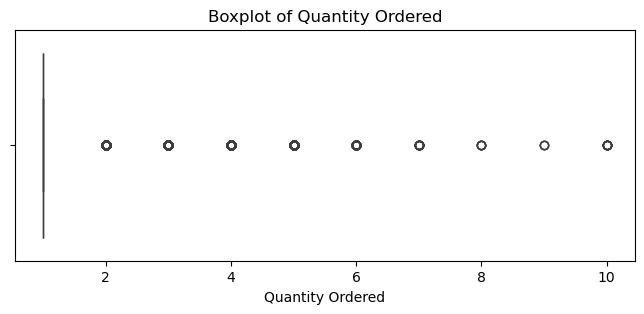

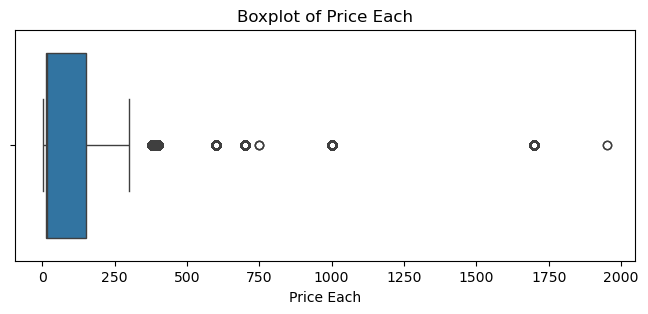

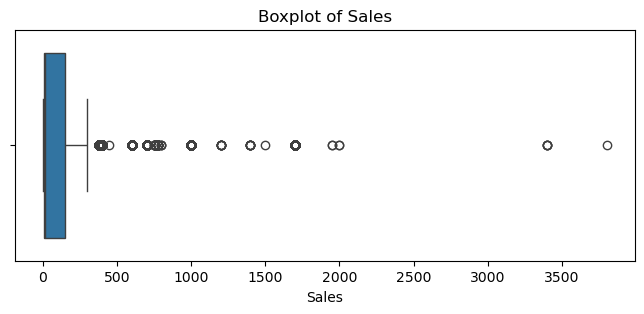

In [31]:
num_cols = ['Quantity Ordered', 'Price Each', 'Sales']
for col in num_cols:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [32]:
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = (df['Sales'] < lower) | (df['Sales'] > upper)

print('Q1:', Q1)
print('Q3:', Q3)
print('IQR:', IQR)
print('Lower Limit:', lower)
print('Upper Limit:', upper)
print('Number of flagged outliers:', outliers.sum(),
      f"({outliers.mean()*100:.1f}% of rows)")

Q1: 11.95
Q3: 150.0
IQR: 138.05
Lower Limit: -195.12500000000003
Upper Limit: 357.07500000000005
Number of flagged outliers: 37015 (19.9% of rows)


## Top 10 products/orders with the highest Sales.

In [33]:
df[['Product', 'Quantity Ordered', 'Price Each', 'Sales']]\
    .sort_values('Sales', ascending=False)\
    .head(10)

,Product,Quantity Ordered,Price Each,Sales
172054,34in Ultrawide Monitor,10,379.99,3799.90
30183,Macbook Pro Laptop,2,1700.00,3400.00
29683,Macbook Pro Laptop,2,1700.00,3400.00
89114,Macbook Pro Laptop,2,1700.00,3400.00
172777,Macbook Pro Laptop,2,1700.00,3400.00
145546,ThinkPad Laptop,2,999.99,1999.98
136628,ThinkPad Laptop,2,999.99,1999.98
77762,27in 4K Gaming Monitor,1,1949.95,1949.95
12079,27in 4K Gaming Monitor,1,1949.95,1949.95
167936,Macbook Pro Laptop,1,1700.00,1700.00


# Step 4 — Feature Engineering

## Feature Engineering Summary

Most useful features were created during **Step 3 (Data Cleaning)**.  
This step only **documents and verifies** them. No new columns are added and the dataset used for the Power BI dashboard is left unchanged.

| Feature | How it was created | Purpose |
|---------|--------------------|---------|
| `Order_Date` | From `Order Date` (date part) | Daily / trend analysis |
| `Order_Time` | From `Order Date` (time part) | Time-of-day patterns |
| `Order Hour` | Renamed from `Hour` | Hourly sales / peak hours |
| `City` | Already in data (from address) | City-wise sales |
| `State` | Extracted from `Purchase Address`, mapped to full names | State-level reporting |
| `Sales` | `Quantity Ordered × Price Each` (validated) | Revenue metrics |
| `Quantity Ordered` | Cast to `int` | Clean counts for charts |

**Note:** Temporary helper columns (e.g. `Calculated Sales`) were dropped after validation. Final column set is fixed for the Power BI dashboard.

In [68]:
# Current columns after cleaning (no changes made here)
print("Current columns in df:")
print(list(df.columns))
print("\nShape:", df.shape)

Current columns in df:
['Order ID', 'Product', 'Quantity Ordered', 'Price Each', 'Purchase Address', 'Sales', 'City', 'Order Hour', 'Order Date', 'Order Time', 'State']

Shape: (185586, 11)


In [69]:
# Validate Sales without permanently adding a column
sales_ok = (
    (df['Sales'] - df['Quantity Ordered'] * df['Price Each'])
    .abs()
    .max()
)
print("Max |Sales - Qty × Price|:", sales_ok)
print("Sales column is consistent with Quantity × Price." if sales_ok == 0
      else "Warning: small floating-point differences may exist.")

Max |Sales - Qty × Price|: 5.684341886080802e-14


# Step 5 — Final Dataset Check

In [34]:
df.shape

(185850, 11)

In [35]:
print("Exact duplicates:", df.duplicated().sum())
print("Total rows:", len(df))

Exact duplicates: 264
Total rows: 185850


In [36]:
df[df.duplicated(keep=False)]

,Order ID,Product,Quantity Ordered,Price Each,Purchase Address,Sales,City,Order Hour,Order_Date,Order_Time,State
437,296081,Flatscreen TV,1,300.00,"970 Sunset St, Austin, TX 73301",300.00,Austin,16,2019-12-30,16:52:00,Texas
438,296081,Flatscreen TV,1,300.00,"970 Sunset St, Austin, TX 73301",300.00,Austin,16,2019-12-30,16:52:00,Texas
1726,297311,Bose SoundSport Headphones,1,99.99,"858 Willow St, Los Angeles, CA 90001",99.99,Los Angeles,7,2019-12-07,07:30:00,California
1727,297311,Bose SoundSport Headphones,1,99.99,"858 Willow St, Los Angeles, CA 90001",99.99,Los Angeles,7,2019-12-07,07:30:00,California
2811,298358,Apple Airpods Headphones,1,150.00,"482 8th St, San Francisco, CA 94016",150.00,San Francisco,15,2019-12-04,15:57:00,California
...,...,...,...,...,...,...,...,...,...,...,...
183323,220392,Lightning Charging Cable,1,14.95,"472 8th St, Portland, ME 04101",14.95,Portland,17,2019-06-08,17:13:00,Maine
183825,220882,Lightning Charging Cable,1,14.95,"588 Lake St, Boston, MA 02215",14.95,Boston,17,2019-06-13,17:53:00,Massachusetts
183826,220882,Lightning Charging Cable,1,14.95,"588 Lake St, Boston, MA 02215",14.95,Boston,17,2019-06-13,17:53:00,Massachusetts
184690,221711,Bose SoundSport Headphones,1,99.99,"139 West St, New York City, NY 10001",99.99,New York City,16,2019-06-15,16:36:00,New York


In [37]:
# Remove exact duplicate rows
df = df.drop_duplicates()

# Verify
print("Exact duplicates:", df.duplicated().sum())
print("Total rows:", len(df))

Exact duplicates: 0
Total rows: 185586


In [38]:
df[df['Order ID'] == 296081]

,Order ID,Product,Quantity Ordered,Price Each,Purchase Address,Sales,City,Order Hour,Order_Date,Order_Time,State
437,296081,Flatscreen TV,1,300.0,"970 Sunset St, Austin, TX 73301",300.0,Austin,16,2019-12-30,16:52:00,Texas


In [39]:
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Purchase Address,Sales,City,Order Hour,Order_Date,Order_Time,State
0,295665,Macbook Pro Laptop,1,1700.00,"136 Church St, New York City, NY 10001",1700.00,New York City,0,2019-12-30,00:01:00,New York
1,295666,LG Washing Machine,1,600.00,"562 2nd St, New York City, NY 10001",600.00,New York City,7,2019-12-29,07:03:00,New York
2,295667,USB-C Charging Cable,1,11.95,"277 Main St, New York City, NY 10001",11.95,New York City,18,2019-12-12,18:21:00,New York
3,295668,27in FHD Monitor,1,149.99,"410 6th St, San Francisco, CA 94016",149.99,San Francisco,15,2019-12-22,15:13:00,California
4,295669,USB-C Charging Cable,1,11.95,"43 Hill St, Atlanta, GA 30301",11.95,Atlanta,12,2019-12-18,12:38:00,Georgia


In [40]:
df.describe()

,Order ID,Quantity Ordered,Price Each,Sales,Order Hour
count,185586.000000,185586.000000,185586.000000,185586.000000,185586.000000
mean,230410.011342,1.125042,184.566525,185.689248,14.413269
std,51510.025636,0.447847,332.953307,333.259460,5.423427
min,141234.000000,1.000000,2.990000,2.990000,0.000000
25%,185834.250000,1.000000,11.950000,11.950000,11.000000
50%,230348.500000,1.000000,14.950000,14.950000,15.000000
75%,275028.750000,1.000000,150.000000,150.000000,19.000000
max,319670.000000,10.000000,1949.950000,3799.900000,23.000000


In [41]:
df.nunique()

Order ID            178350
Product                 19
Quantity Ordered        10
Price Each              21
Purchase Address    140731
Sales                   61
City                     9
Order Hour              24
Order_Date             366
Order_Time            1440
State                    8
dtype: int64

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 185586 entries, 0 to 185949
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Order ID          185586 non-null  int64  
 1   Product           185586 non-null  object 
 2   Quantity Ordered  185586 non-null  int32  
 3   Price Each        185586 non-null  float64
 4   Purchase Address  185586 non-null  object 
 5   Sales             185586 non-null  float64
 6   City              185586 non-null  object 
 7   Order Hour        185586 non-null  int64  
 8   Order_Date        185586 non-null  object 
 9   Order_Time        185586 non-null  object 
 10  State             185586 non-null  object 
dtypes: float64(2), int32(1), int64(2), object(6)
memory usage: 16.3+ MB


In [43]:
df.isnull().sum()

Order ID            0
Product             0
Quantity Ordered    0
Price Each          0
Purchase Address    0
Sales               0
City                0
Order Hour          0
Order_Date          0
Order_Time          0
State               0
dtype: int64

# Step 6 — Exploratory Data Analysis (EDA)

## Product Frequency

In [44]:
df['Product'].value_counts()

Product
USB-C Charging Cable          21846
Lightning Charging Cable      21599
AAA Batteries (4-pack)        20598
AA Batteries (4-pack)         20554
Wired Headphones              18841
Apple Airpods Headphones      15516
Bose SoundSport Headphones    13293
27in FHD Monitor               7486
iPhone                         6835
27in 4K Gaming Monitor         6222
34in Ultrawide Monitor         6172
Google Phone                   5518
Flatscreen TV                  4791
Macbook Pro Laptop             4721
ThinkPad Laptop                4125
20in Monitor                   4093
Vareebadd Phone                2064
LG Washing Machine              666
LG Dryer                        646
Name: count, dtype: int64

### a. Product-wise Quantity

In [45]:
product_quantity = (
    df.groupby('Product')['Quantity Ordered']
      .sum()
      .sort_values(ascending=False)
)
product_quantity

Product
AAA Batteries (4-pack)        30973
AA Batteries (4-pack)         27628
USB-C Charging Cable          23935
Lightning Charging Cable      23176
Wired Headphones              20525
Apple Airpods Headphones      15628
Bose SoundSport Headphones    13425
27in FHD Monitor               7538
iPhone                         6842
27in 4K Gaming Monitor         6236
34in Ultrawide Monitor         6199
Google Phone                   5525
Flatscreen TV                  4810
Macbook Pro Laptop             4725
ThinkPad Laptop                4127
20in Monitor                   4121
Vareebadd Phone                2067
LG Washing Machine              666
LG Dryer                        646
Name: Quantity Ordered, dtype: int32

### b. Product-wise Revenue

In [46]:
product_sales = (
    df.groupby('Product')['Sales']
      .sum()
      .sort_values(ascending=False)
)
product_sales

Product
Macbook Pro Laptop            8032500.00
iPhone                        4789400.00
ThinkPad Laptop               4126958.73
Google Phone                  3315000.00
27in 4K Gaming Monitor        2435097.56
34in Ultrawide Monitor        2355558.01
Apple Airpods Headphones      2346000.00
Flatscreen TV                 1443000.00
Bose SoundSport Headphones    1342365.75
27in FHD Monitor              1130624.62
Vareebadd Phone                826800.00
20in Monitor                   453268.79
LG Washing Machine             399600.00
LG Dryer                       387600.00
Lightning Charging Cable       346481.20
USB-C Charging Cable           286166.65
Wired Headphones               246190.67
AA Batteries (4-pack)          106091.52
AAA Batteries (4-pack)          92621.23
Name: Sales, dtype: float64

### c. Visualize Product Revenue

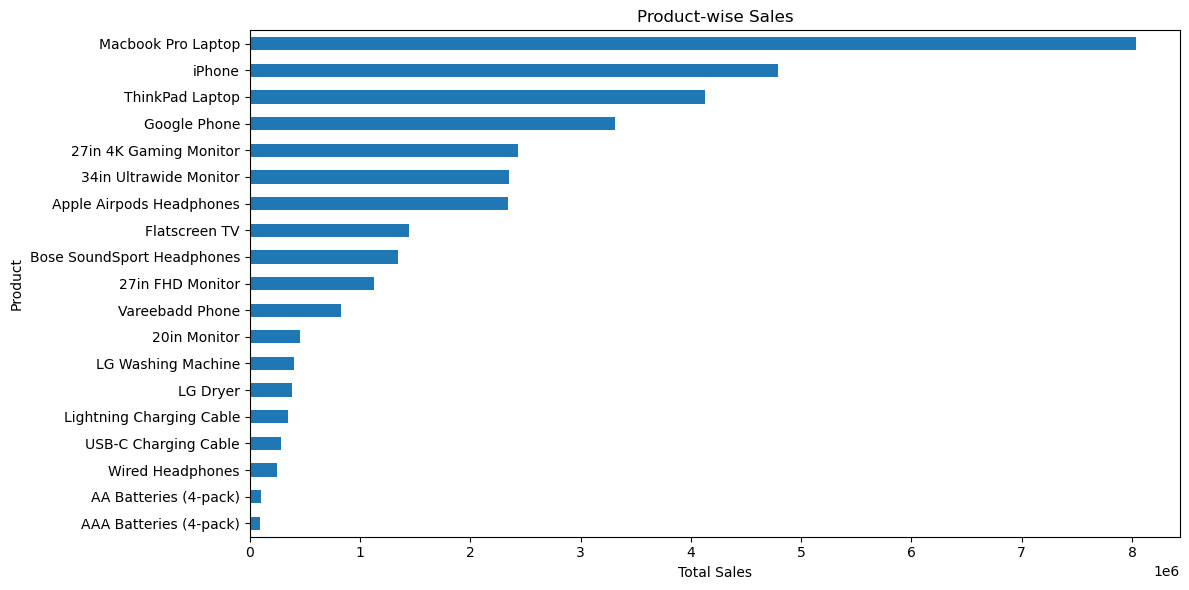

In [47]:
plt.figure(figsize=(12, 6))
product_sales.sort_values().plot(kind='barh')
plt.xlabel('Total Sales')
plt.ylabel('Product')
plt.title('Product-wise Sales')
plt.tight_layout()
plt.show()

## Monthly Sales Analysis

In [48]:
monthly_sales = df.groupby('Order_Date')['Sales'].sum()
monthly_sales

Order_Date
2019-01-01     65729.74
2019-01-02     70663.20
2019-01-03     47034.25
2019-01-04     61620.23
2019-01-05     46374.64
                ...    
2019-12-28    133601.53
2019-12-29    156009.67
2019-12-30    151857.82
2019-12-31    131415.42
2020-01-01      8670.29
Name: Sales, Length: 366, dtype: float64

**a. Monthly Visualization**

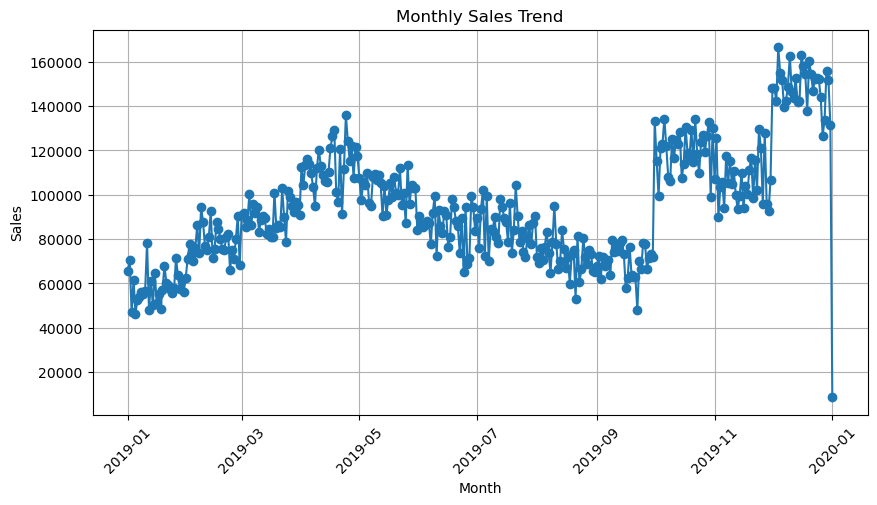

In [49]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.title('Monthly Sales Trend')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## City-wise Sales

In [50]:
city_sales = (
    df.groupby('City')['Sales']
      .sum()
      .sort_values(ascending=False)
)
city_sales

City
San Francisco    8251703.82
Los Angeles      5447692.21
New York City    4662281.63
Boston           3658534.77
Atlanta          2792995.39
Dallas           2764834.89
Seattle          2744736.44
Portland         2322483.94
Austin           1816061.64
Name: Sales, dtype: float64

**a. City-wise Visualization**

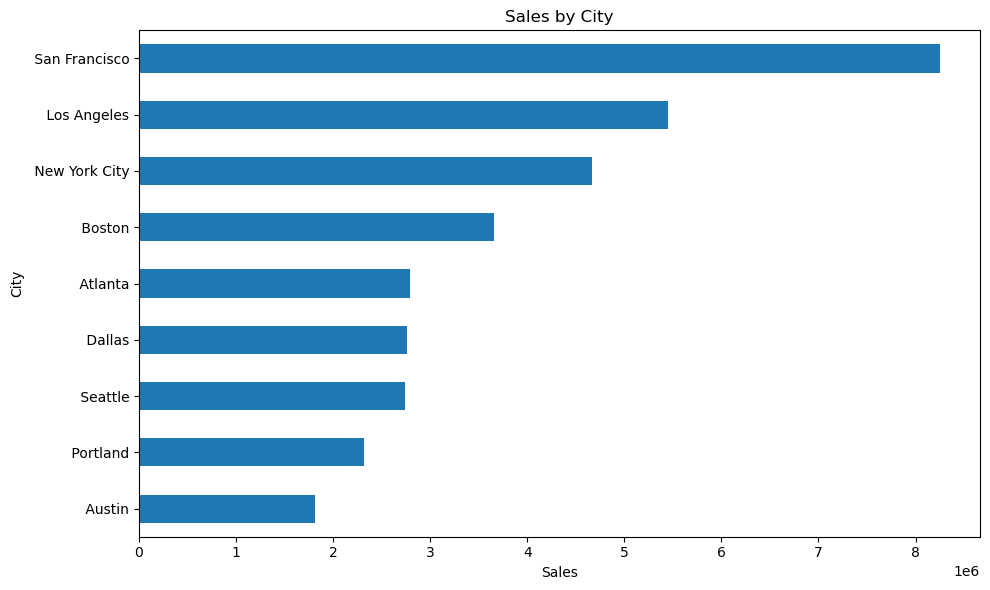

In [51]:
plt.figure(figsize=(10, 6))
city_sales.sort_values().plot(kind='barh')
plt.xlabel('Sales')
plt.ylabel('City')
plt.title('Sales by City')
plt.tight_layout()
plt.show()

## State-wise Sales

In [52]:
state_sales = (
    df.groupby('State')['Sales']
      .sum()
      .sort_values(ascending=False)
)
state_sales

State
California       13699396.03
New York          4662281.63
Texas             4580896.53
Massachusetts     3658534.77
Georgia           2792995.39
Washington        2744736.44
Oregon            1869742.65
Maine              452741.29
Name: Sales, dtype: float64

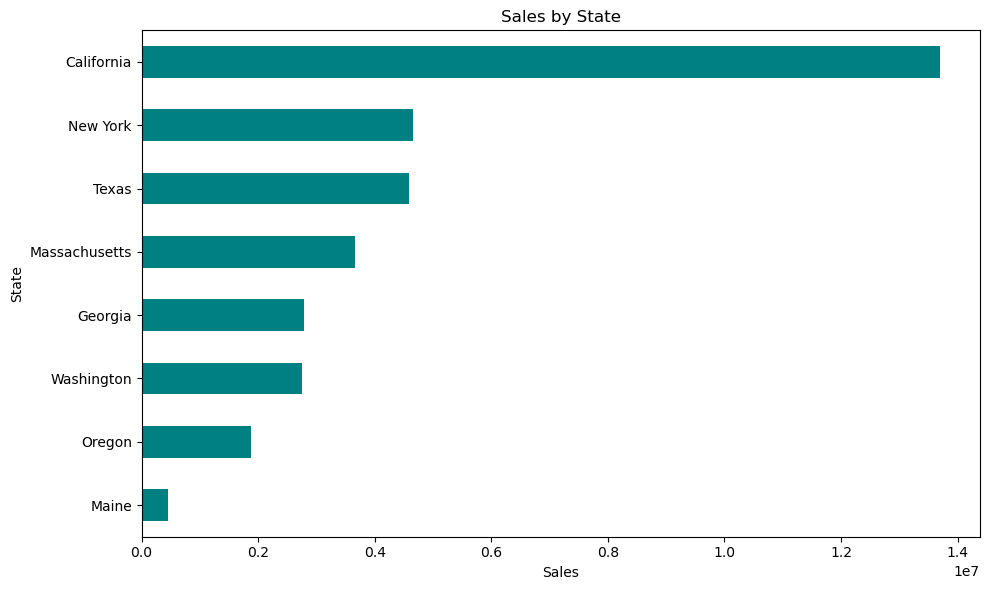

In [53]:
plt.figure(figsize=(10, 6))
state_sales.sort_values().plot(kind='barh', color='teal')
plt.xlabel('Sales')
plt.ylabel('State')
plt.title('Sales by State')
plt.tight_layout()
plt.show()

In [54]:
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Purchase Address,Sales,City,Order Hour,Order_Date,Order_Time,State
0,295665,Macbook Pro Laptop,1,1700.00,"136 Church St, New York City, NY 10001",1700.00,New York City,0,2019-12-30,00:01:00,New York
1,295666,LG Washing Machine,1,600.00,"562 2nd St, New York City, NY 10001",600.00,New York City,7,2019-12-29,07:03:00,New York
2,295667,USB-C Charging Cable,1,11.95,"277 Main St, New York City, NY 10001",11.95,New York City,18,2019-12-12,18:21:00,New York
3,295668,27in FHD Monitor,1,149.99,"410 6th St, San Francisco, CA 94016",149.99,San Francisco,15,2019-12-22,15:13:00,California
4,295669,USB-C Charging Cable,1,11.95,"43 Hill St, Atlanta, GA 30301",11.95,Atlanta,12,2019-12-18,12:38:00,Georgia


## Hour-wise Sales

In [55]:
hourly_sales = df.groupby('Order Hour')['Sales'].sum()
hourly_sales

Order Hour
0      713276.22
1      460278.01
2      234239.45
3      145742.94
4      162546.07
5      230664.87
6      447963.01
7      747487.23
8     1192361.85
9     1638860.16
10    1941831.25
11    2295578.00
12    2313200.31
13    2150169.83
14    2083790.71
15    1940024.04
16    1901731.36
17    2127592.14
18    2217419.20
19    2411667.65
20    2280706.72
21    2040024.94
22    1605790.90
23    1178377.87
Name: Sales, dtype: float64

**a. Hour-wise Visualization**

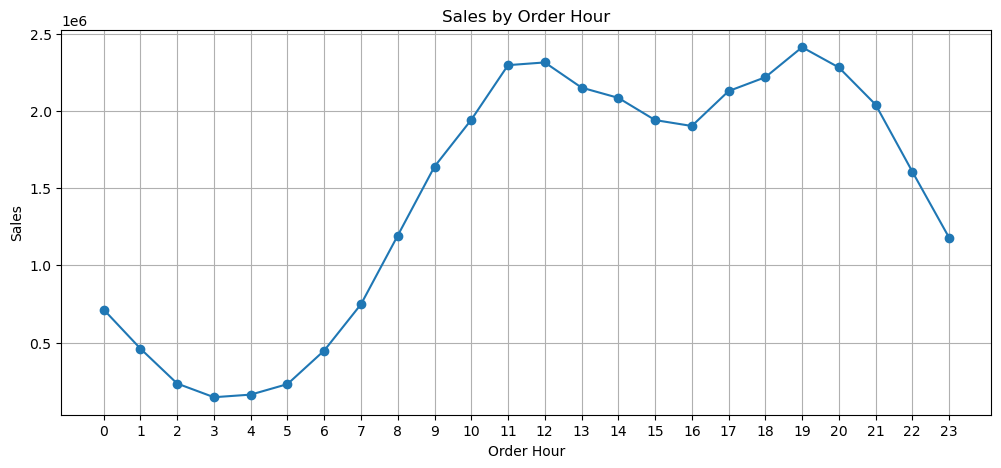

In [56]:


plt.figure(figsize=(12, 5))
plt.plot(hourly_sales.index, hourly_sales.values, marker='o')

plt.xlabel('Order Hour')
plt.ylabel('Sales')
plt.title('Sales by Order Hour')

plt.xticks(range(24))
plt.grid(True)

plt.show()

## Quantity vs Sales

In [57]:
quantity_sales = df.groupby('Quantity Ordered')['Sales'].sum()
quantity_sales

Quantity Ordered
1     34072860.56
2       323540.52
3        40997.13
4        11710.76
5         3866.25
6         1570.56
7          514.22
8          119.60
9           80.73
10        6064.40
Name: Sales, dtype: float64

**Quantity vs Sales Visualization**

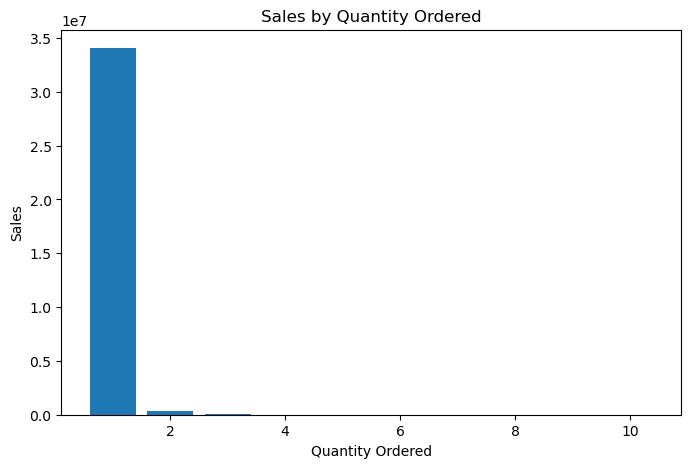

In [58]:
plt.figure(figsize=(8, 5))
plt.bar(quantity_sales.index, quantity_sales.values)
plt.xlabel('Quantity Ordered')
plt.ylabel('Sales')
plt.title('Sales by Quantity Ordered')
plt.show()

## Price vs Sales

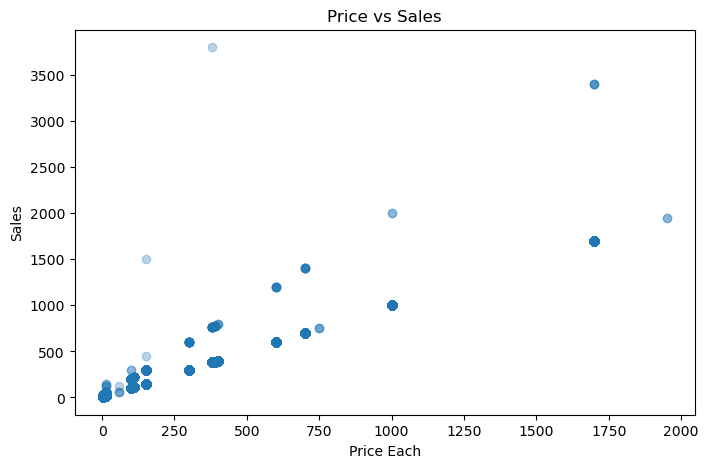

In [59]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Price Each'], df['Sales'], alpha=0.3)
plt.xlabel('Price Each')
plt.ylabel('Sales')
plt.title('Price vs Sales')
plt.show()

## Correlation Analysis

In [60]:
corr = df[['Quantity Ordered', 'Price Each', 'Sales', 'Order Hour']].corr()
corr

,Quantity Ordered,Price Each,Sales,Order Hour
Quantity Ordered,1.000000,-0.147244,-0.136685,-0.002255
Price Each,-0.147244,1.000000,0.998873,0.001786
Sales,-0.136685,0.998873,1.000000,0.001635
Order Hour,-0.002255,0.001786,0.001635,1.000000


**Visualization**
*(Improved — annotated with actual correlation values instead of an unlabeled color grid.)*

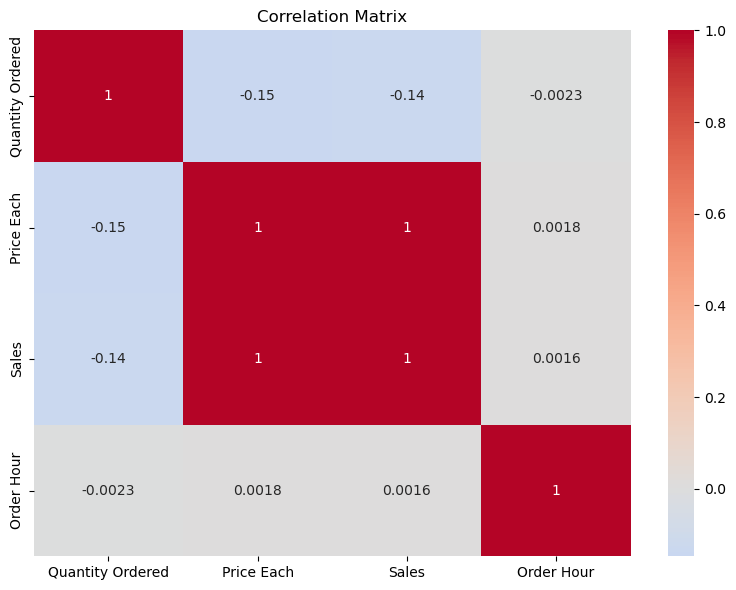

In [61]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [62]:
df.head(2)

,Order ID,Product,Quantity Ordered,Price Each,Purchase Address,Sales,City,Order Hour,Order_Date,Order_Time,State
0,295665,Macbook Pro Laptop,1,1700.0,"136 Church St, New York City, NY 10001",1700.0,New York City,0,2019-12-30,00:01:00,New York
1,295666,LG Washing Machine,1,600.0,"562 2nd St, New York City, NY 10001",600.0,New York City,7,2019-12-29,07:03:00,New York


## Products Frequently Bought Together
*(New — the dataset's `Order ID` repeats when a single order contains multiple products. This was never used in the original notebook. Finding which product pairs co-occur most often is one of the most actionable insights this data supports — e.g. for bundling or cross-sell recommendations.)*

In [63]:


df = df.rename(columns={
    'Order_Date': 'Order Date',
    'Order_Time': 'Order Time'
})

multi_item_orders = df[
    df.duplicated(subset=['Order ID'], keep=False)
]

order_products = (
    multi_item_orders
    .groupby('Order ID')
    .agg(
        Order_Date=('Order Date', 'first'),
        Products=('Product', lambda x: sorted(set(x)))
    )
)

pair_rows = []

for order_id, row in order_products.iterrows():
    products = row['Products']

    if len(products) > 1:
        for product_1, product_2 in combinations(products, 2):
            pair_rows.append({
                'Order Date': row['Order_Date'],
                'Order ID': order_id,
                'Product 1': product_1,
                'Product 2': product_2,
                'Product Pair': f'{product_1} + {product_2}',
                'Pair Count': 1
            })

product_pairs = pd.DataFrame(
    pair_rows,
    columns=[
        'Order Date',
        'Order ID',
        'Product 1',
        'Product 2',
        'Product Pair',
        'Pair Count'
    ]
)

top_pairs = (
    product_pairs
    .groupby('Product Pair')['Pair Count']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
    .rename(columns={
        'Pair Count': 'Times Bought Together'
    })
)

top_pairs

,Product Pair,Times Bought Together
0,Lightning Charging Cable + iPhone,1008
1,Google Phone + USB-C Charging Cable,994
2,Wired Headphones + iPhone,462
3,Google Phone + Wired Headphones,422
4,Apple Airpods Headphones + iPhone,372
5,USB-C Charging Cable + Vareebadd Phone,368
6,Bose SoundSport Headphones + Google Phone,228
7,USB-C Charging Cable + Wired Headphones,203
8,Vareebadd Phone + Wired Headphones,149
9,Lightning Charging Cable + Wired Headphones,129


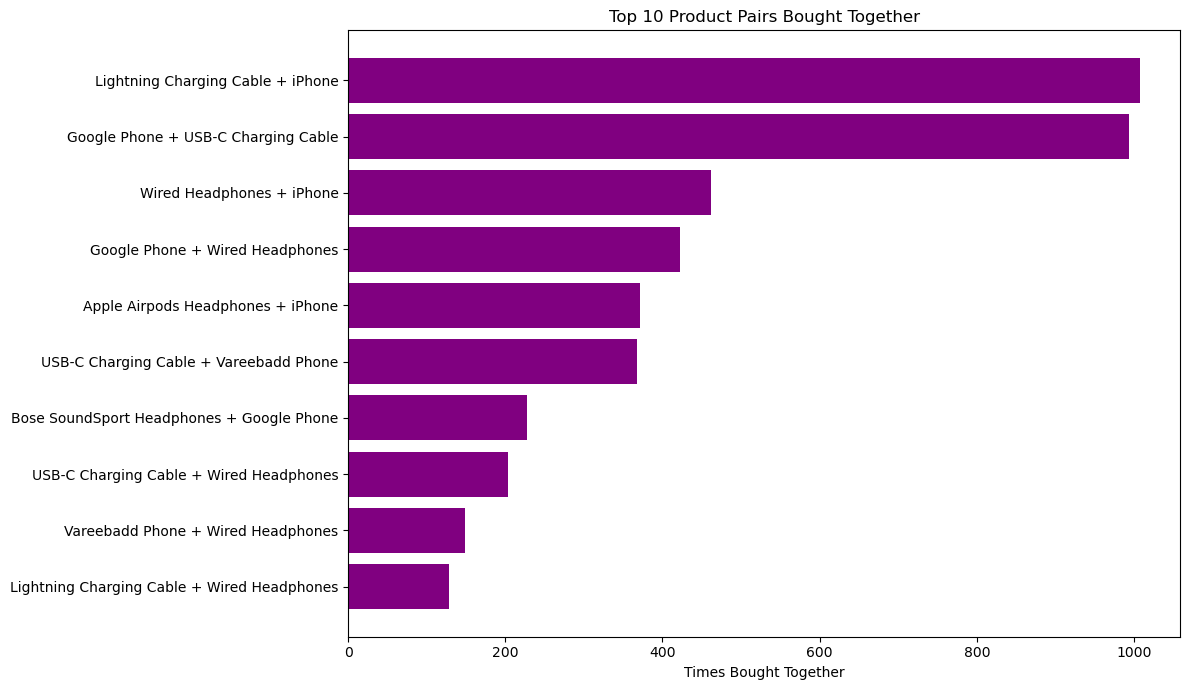

In [64]:


plt.figure(figsize=(12, 7))

labels = top_pairs['Product Pair']

plt.barh(
    labels[::-1],
    top_pairs['Times Bought Together'][::-1],
    color='purple'
)

plt.xlabel('Times Bought Together')
plt.title('Top 10 Product Pairs Bought Together')
plt.tight_layout()
plt.show()

## Average Order Value (AOV)

In [65]:
total_sales = df['Sales'].sum()
unique_orders = df['Order ID'].nunique()
total_quantity = df['Quantity Ordered'].sum()

AOV = total_sales / unique_orders
average_selling_price = df['Price Each'].mean()

print('Total Sales:', round(total_sales, 2))
print('Total Orders:', unique_orders)
print('Total Quantity:', total_quantity)
print('Average Order Value:', round(AOV, 2))
print('Average Selling Price:', round(average_selling_price, 2))


Total Sales: 34461324.73
Total Orders: 178350
Total Quantity: 208792
Average Order Value: 193.22
Average Selling Price: 184.57


# Step 7 — Save Cleaned Data (Optional)
Uncomment to persist the cleaned dataset for reuse in a dashboard, report, or another notebook.

In [72]:
df.to_csv('Sales_Analysis_Data_cleaned.csv', index=False)
print('Saved Sales_Data_Cleaned.csv')

product_pairs.to_csv('Product_Pairs.csv', index=False)
print('Saved Product_Pairs.csv')


Saved Sales_Data_Cleaned.csv
Saved Product_Pairs.csv


In [67]:
df

,Order ID,Product,Quantity Ordered,Price Each,Purchase Address,Sales,City,Order Hour,Order Date,Order Time,State
0,295665,Macbook Pro Laptop,1,1700.00,"136 Church St, New York City, NY 10001",1700.00,New York City,0,2019-12-30,00:01:00,New York
1,295666,LG Washing Machine,1,600.00,"562 2nd St, New York City, NY 10001",600.00,New York City,7,2019-12-29,07:03:00,New York
2,295667,USB-C Charging Cable,1,11.95,"277 Main St, New York City, NY 10001",11.95,New York City,18,2019-12-12,18:21:00,New York
3,295668,27in FHD Monitor,1,149.99,"410 6th St, San Francisco, CA 94016",149.99,San Francisco,15,2019-12-22,15:13:00,California
4,295669,USB-C Charging Cable,1,11.95,"43 Hill St, Atlanta, GA 30301",11.95,Atlanta,12,2019-12-18,12:38:00,Georgia
...,...,...,...,...,...,...,...,...,...,...,...
185945,222905,AAA Batteries (4-pack),1,2.99,"795 Pine St, Boston, MA 02215",2.99,Boston,19,2019-06-07,19:02:00,Massachusetts
185946,222906,27in FHD Monitor,1,149.99,"495 North St, New York City, NY 10001",149.99,New York City,19,2019-06-01,19:29:00,New York
185947,222907,USB-C Charging Cable,1,11.95,"319 Ridge St, San Francisco, CA 94016",11.95,San Francisco,18,2019-06-22,18:57:00,California
185948,222908,USB-C Charging Cable,1,11.95,"916 Main St, San Francisco, CA 94016",11.95,San Francisco,18,2019-06-26,18:35:00,California
